In [3]:
import warnings
warnings.simplefilter("ignore")
from prepare import train_properties_and_names

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

train_properties, feature_names = train_properties_and_names()
dataset_path = 'data_filled_400.csv'

# read dataset
datas = pd.read_csv(dataset_path)


AttributeError: partially initialized module 'torch' from 'C:\Users\29304\.conda\envs\work\Lib\site-packages\torch\__init__.py' has no attribute 'types' (most likely due to a circular import)

In [3]:
data = datas.drop(['element1','element2'],axis=1)

In [4]:
import numpy as np
import pandas as pd

In [5]:
pd.set_option('display.max_columns',None)
data.describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,0.454545,0.334711,0.210744,11.548486,2.656013,544.958678,9.565483,0.400826,0.157025,0.198347,39.632610,0.163222,90.692514,1.263922,1888.963173,0.347107,0.355372,0.297521,183.330579,47.281184,2.673444,27.904051,44.331074
std,0.498962,0.472867,0.408682,6.507030,1.409359,20.618002,4.962669,0.491082,0.364578,0.399581,123.013812,0.090904,31.763476,3.306101,753.578632,0.477037,0.479618,0.458115,125.227222,25.224681,0.110797,16.070274,17.852660
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.975487,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.137500,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,28.043335,2.616962,15.927819,31.925000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,10.000000,0.000000,0.000000,0.000000,5.665000,0.200000,113.099995,0.600000,2064.334537,0.000000,0.000000,0.000000,150.000000,47.609500,2.680000,25.800000,40.450000
75%,1.000000,1.000000,0.000000,15.000000,3.000000,550.000000,15.000000,1.000000,0.000000,0.000000,25.000000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.636525,2.736553,36.035932,54.420000
max,1.000000,1.000000,1.000000,30.000000,17.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,3.000000,80.500000,93.440000


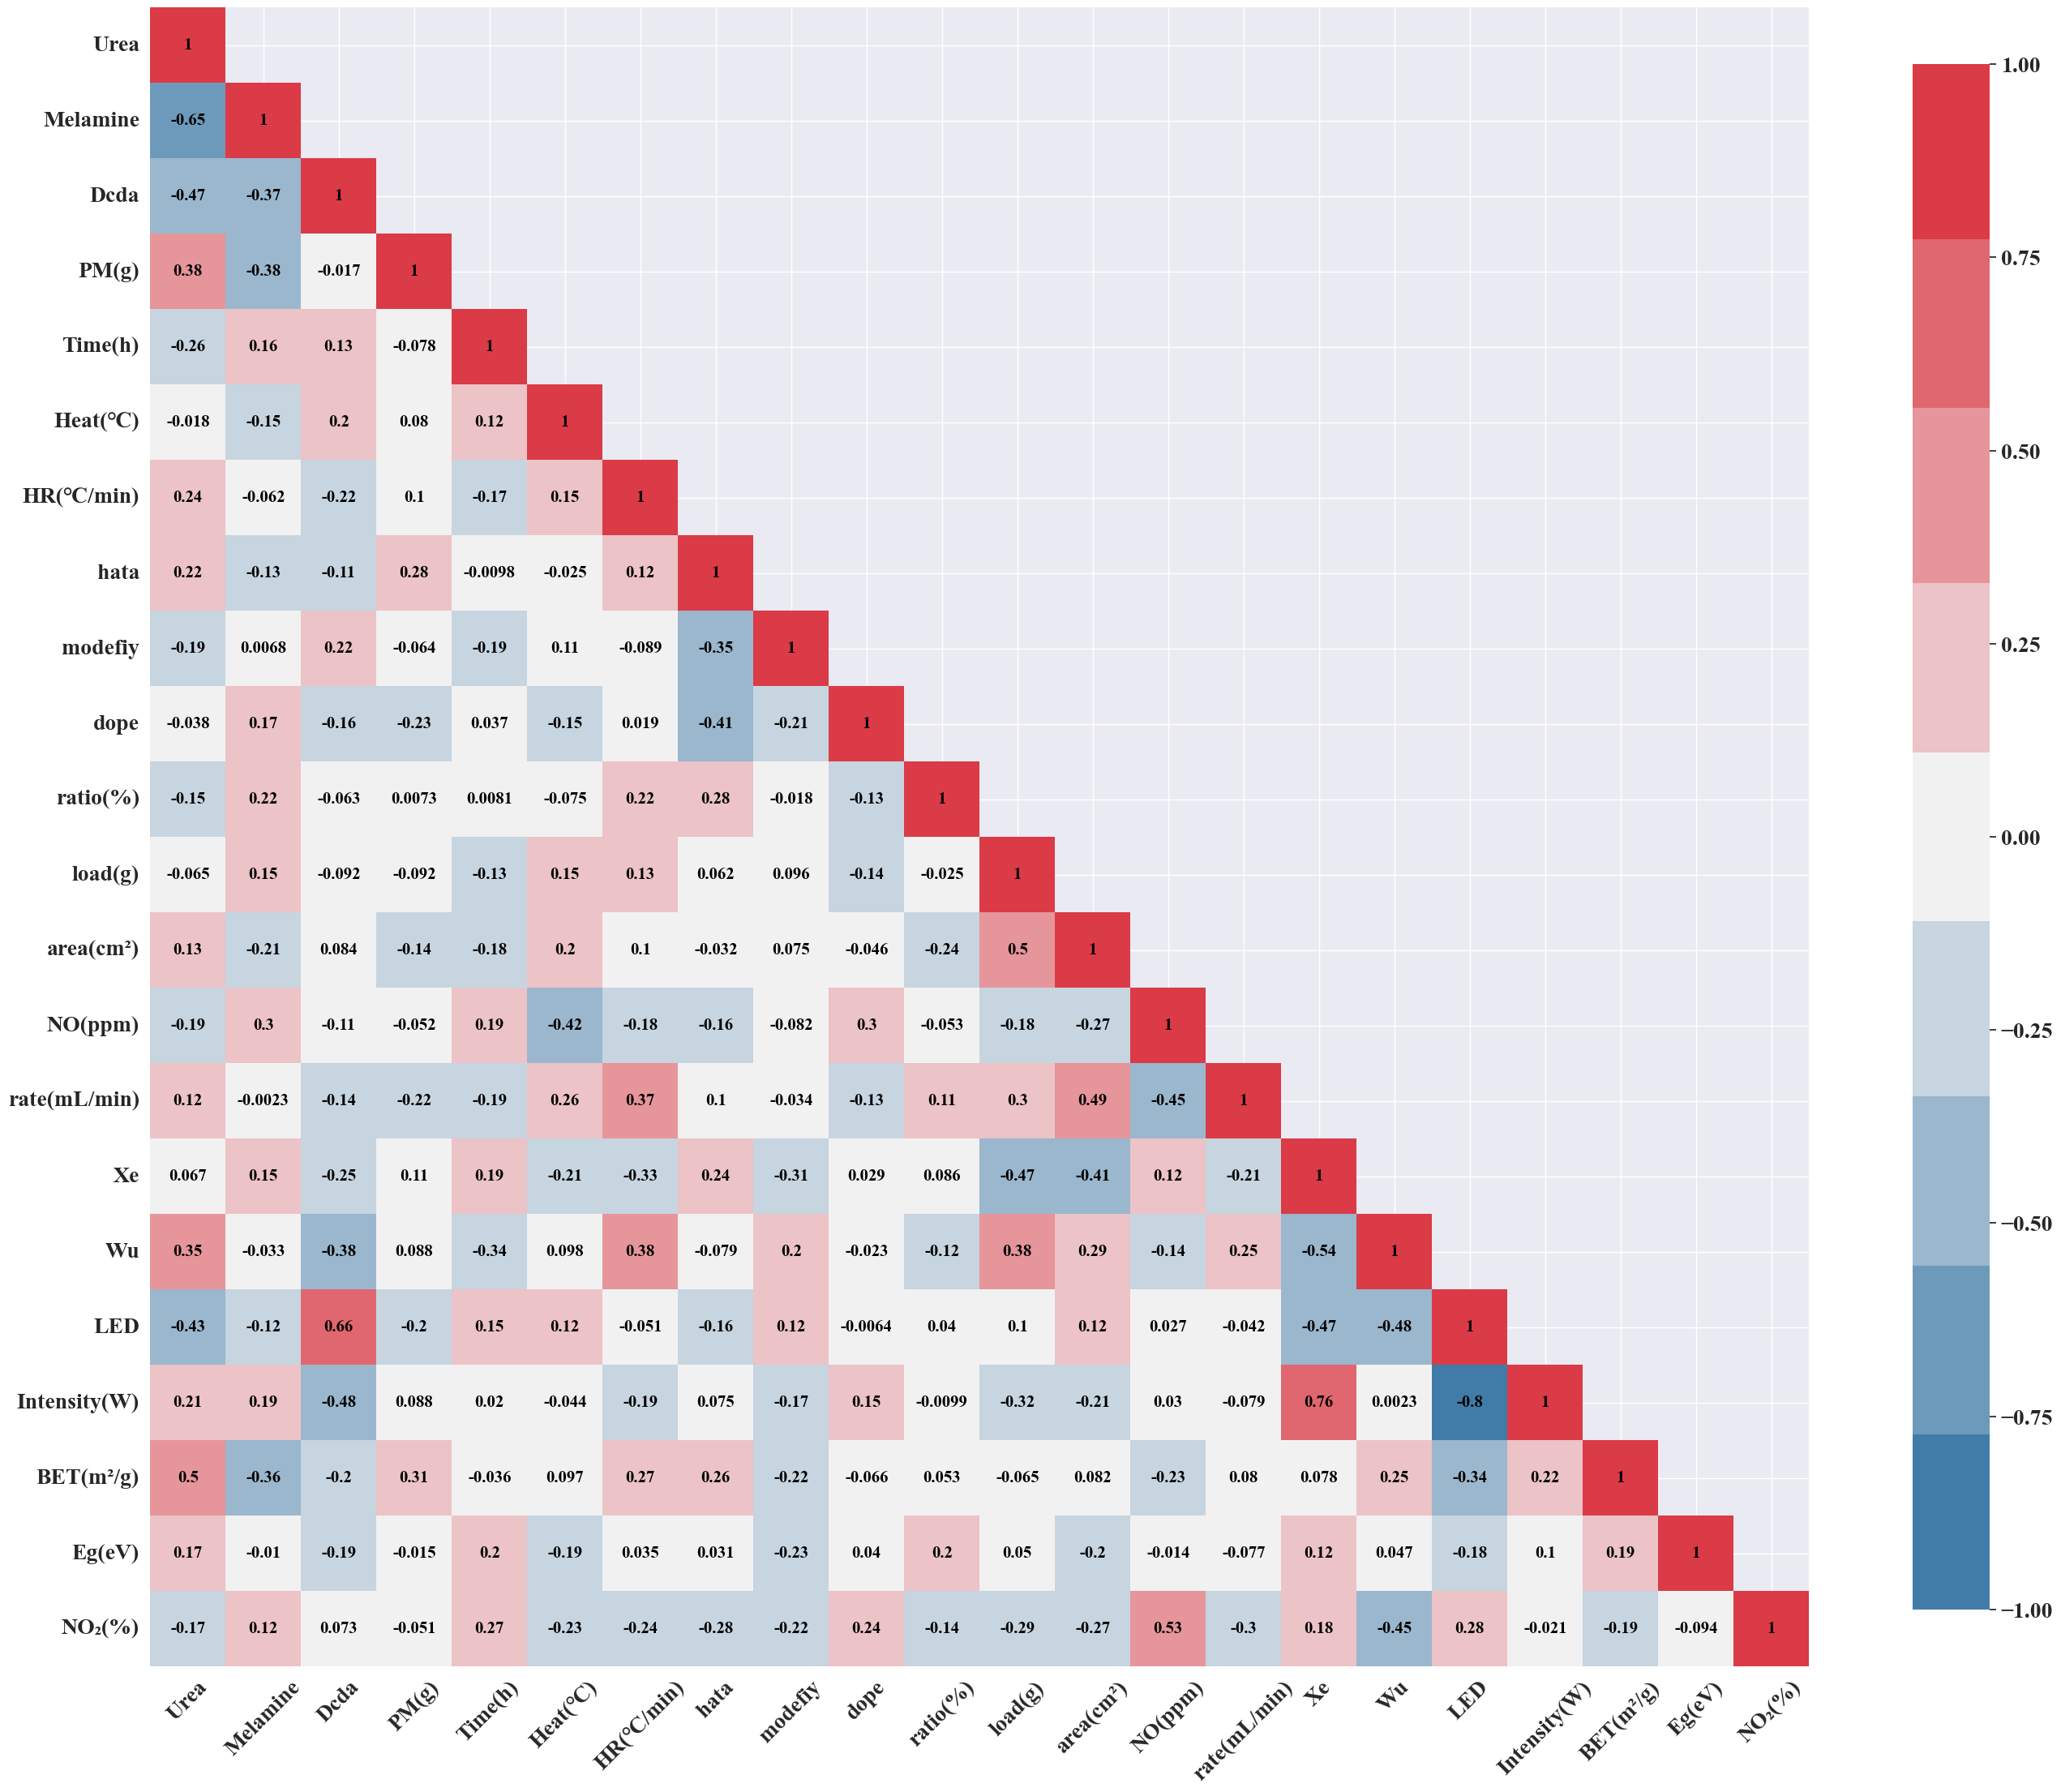

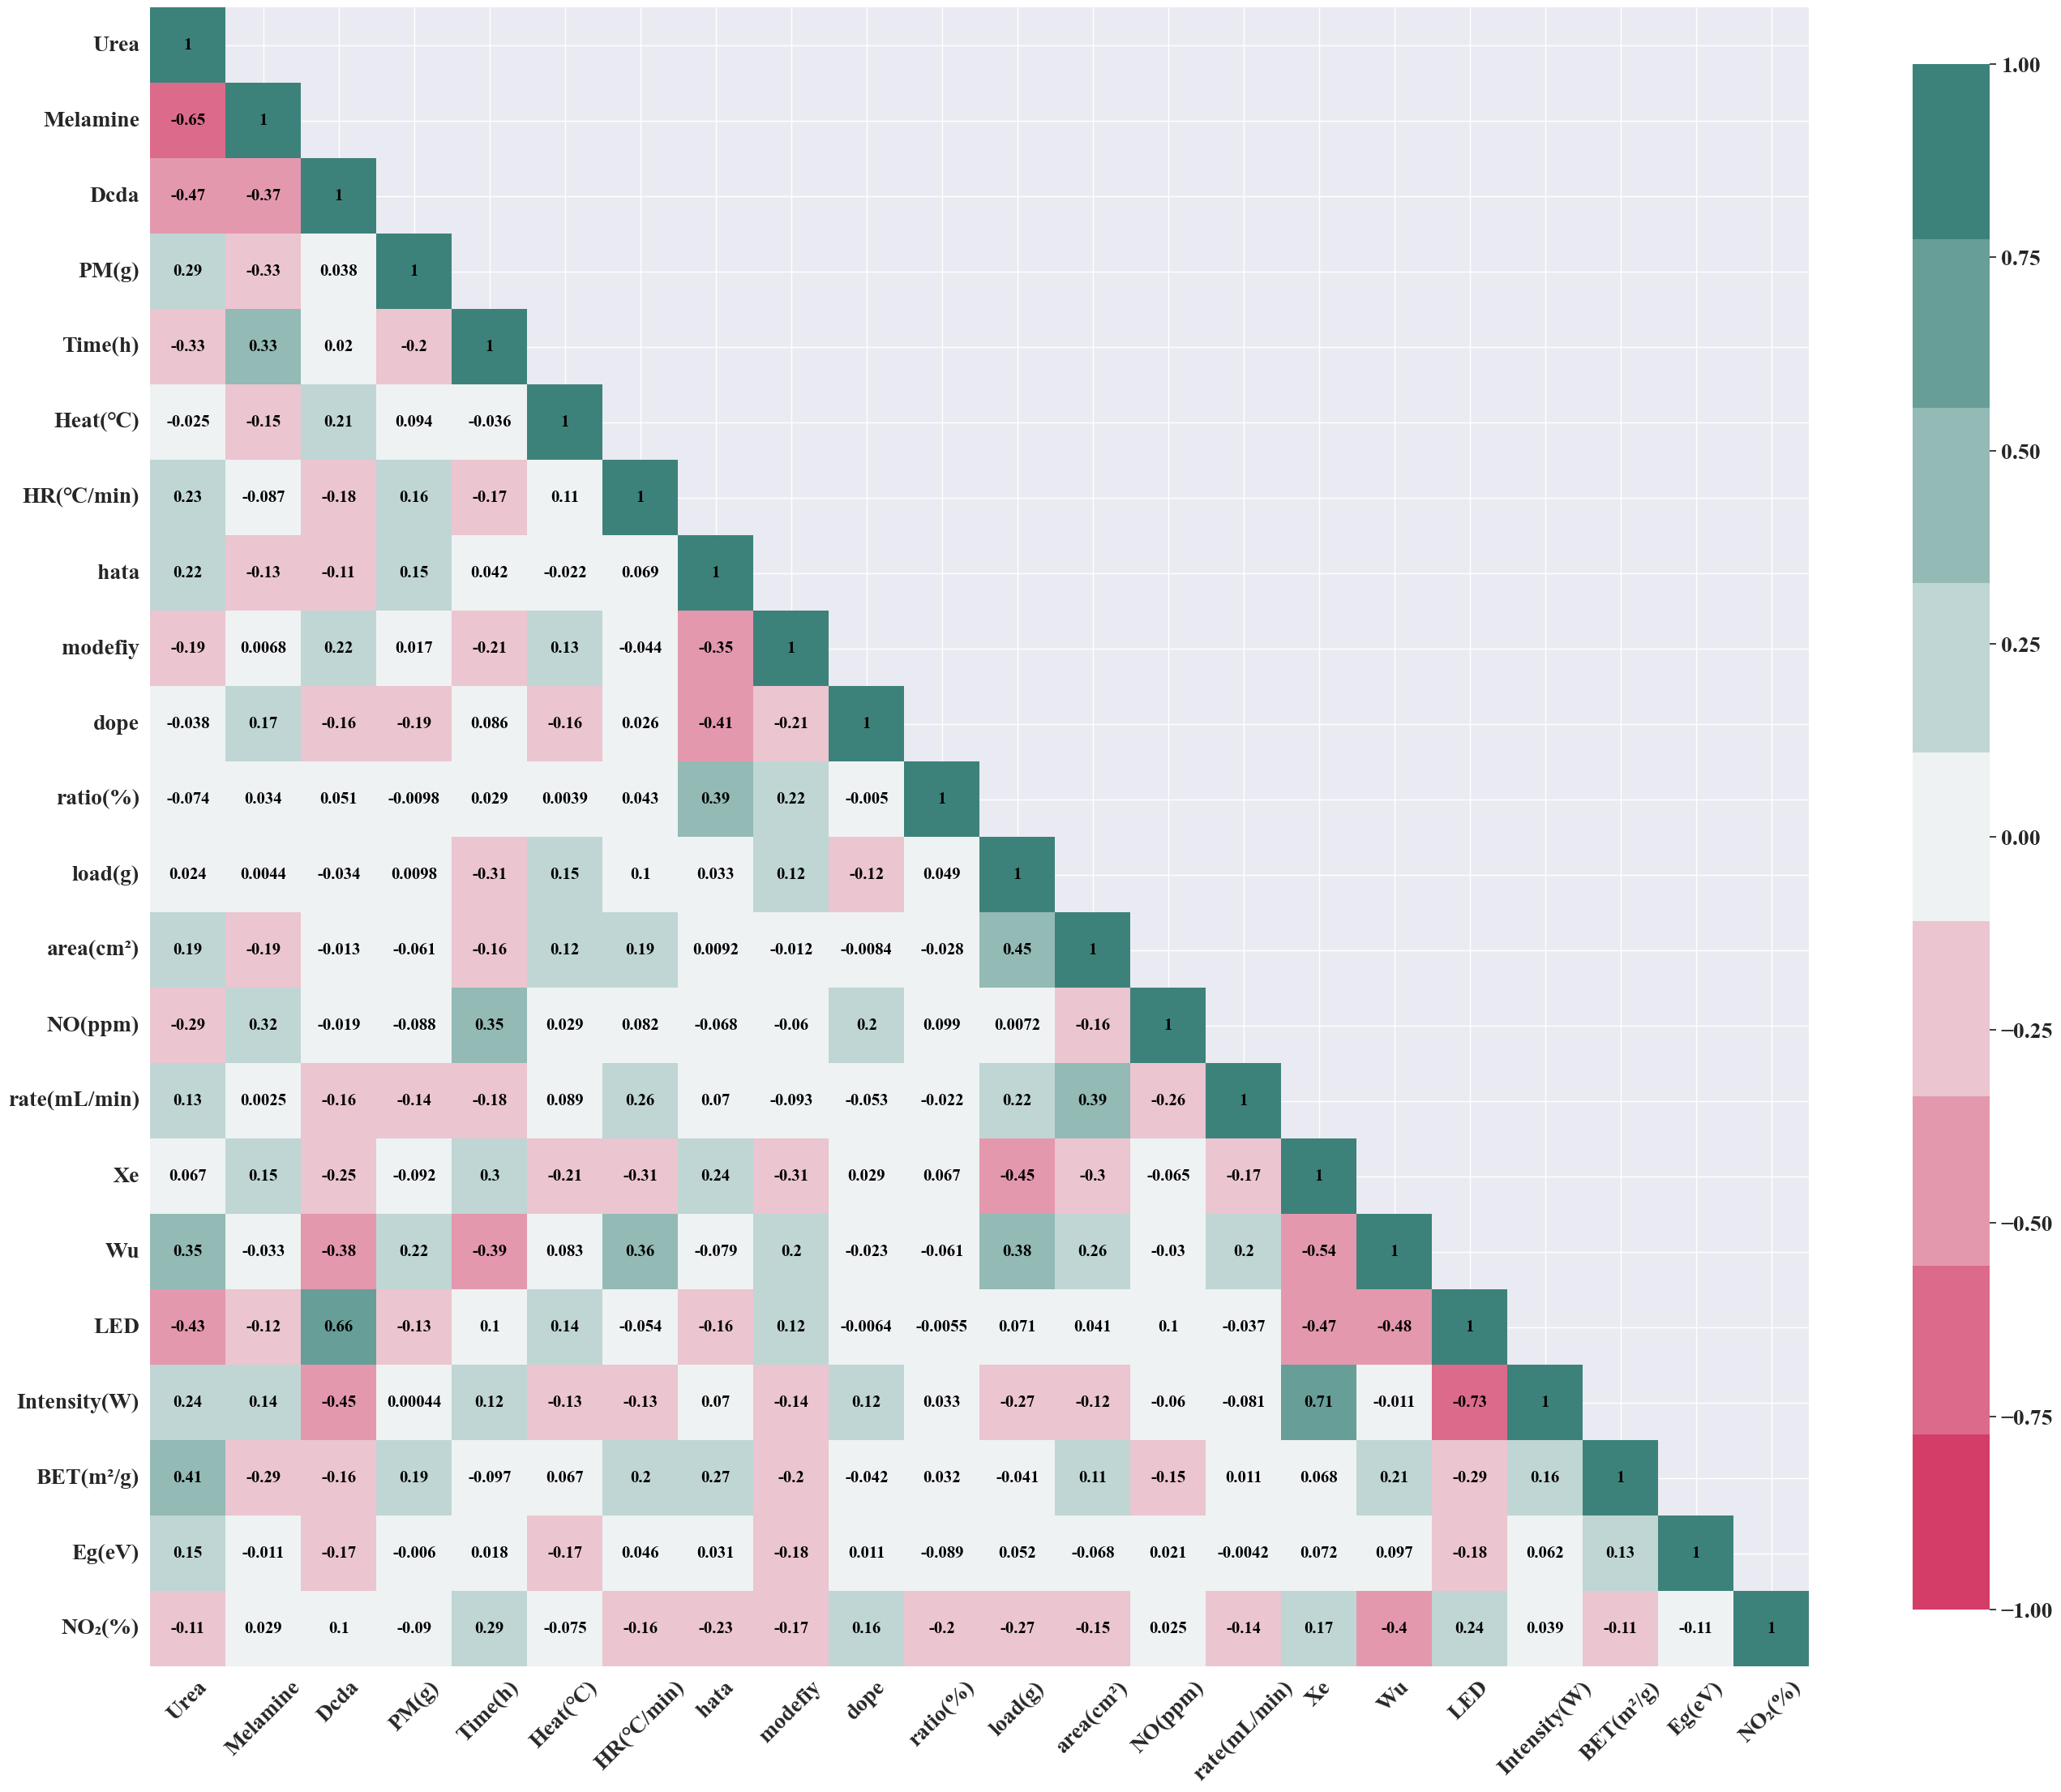

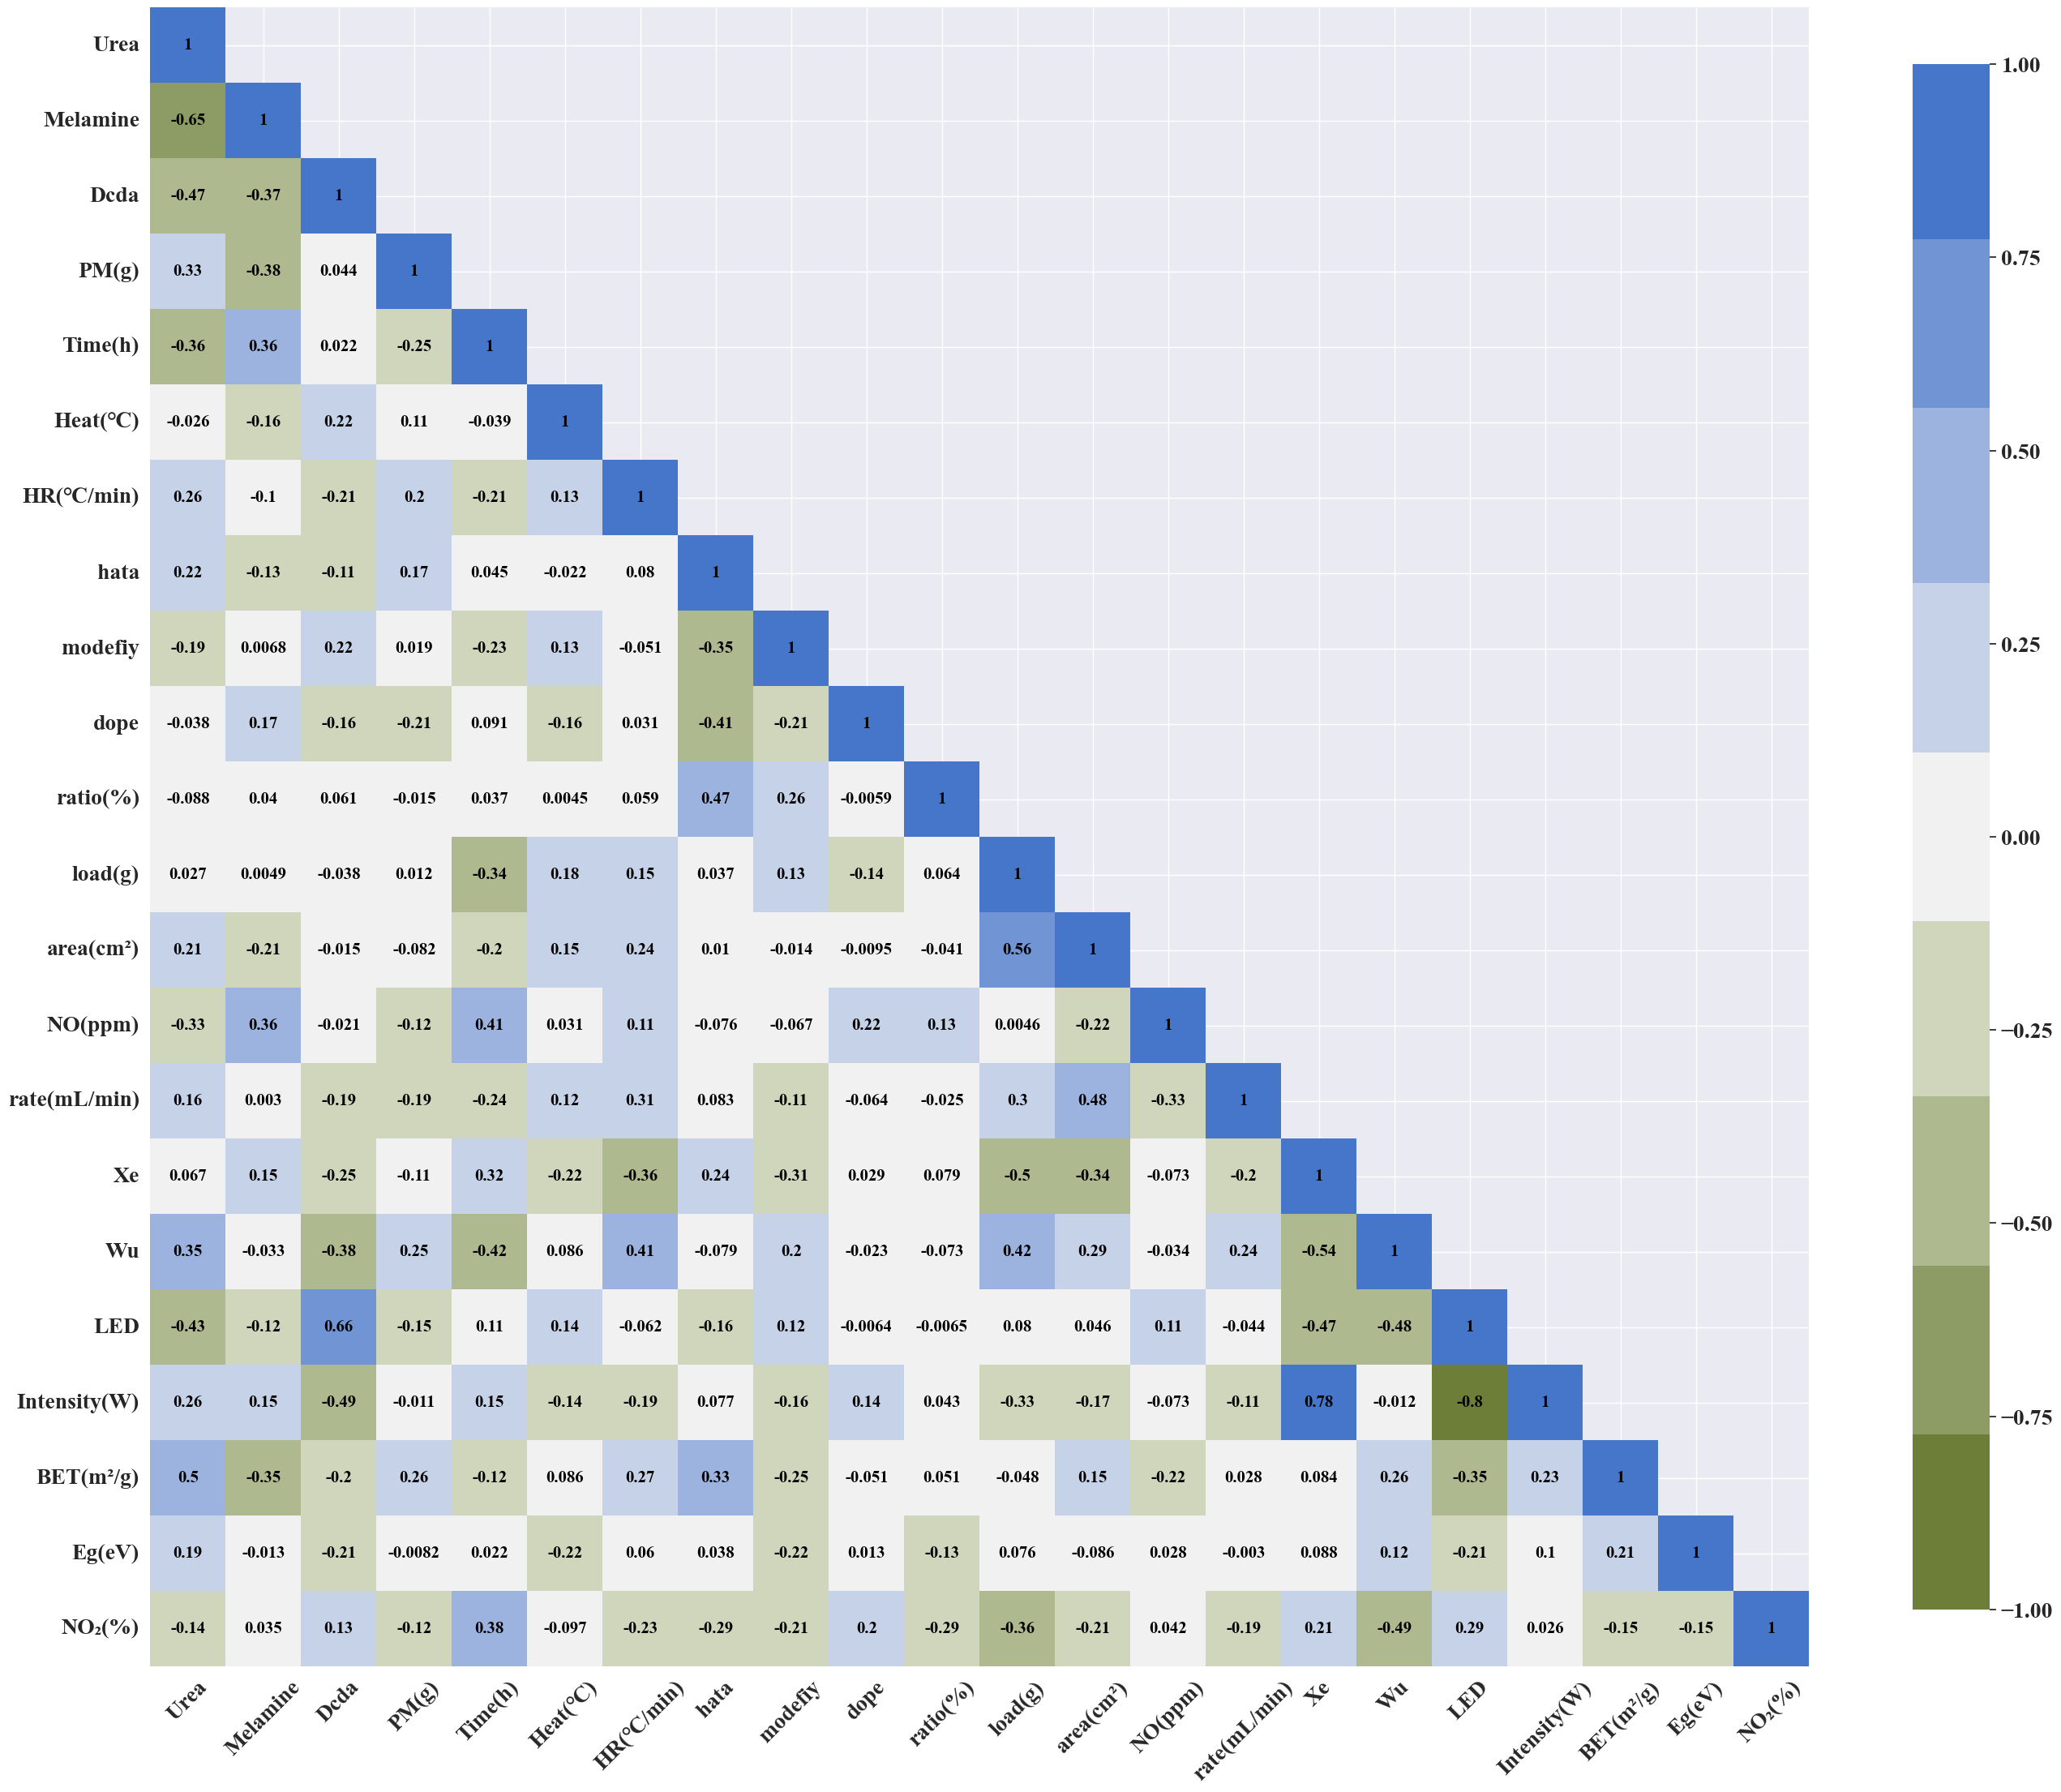

In [29]:
from prepare import draw_heatmap
import seaborn as sns
df = data.drop(['NO(%)'],axis=1)
draw_heatmap(df,'pearson',sns.diverging_palette(240, 10, n=9),size = 20, save = False)
draw_heatmap(df,'kendall',sns.diverging_palette(0, 180, n=9), size = 20,save = False)
draw_heatmap(df,'spearman',sns.diverging_palette(100, 255, n=9), size= 20,save = False)


In [30]:
target = datas['NO(%)']


In [41]:
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from prepare import process_regressor, model_performance_metrics,draw_scatter
datas = pd.read_csv(dataset_path)
x_train, x_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=352)

dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
et = ExtraTreesRegressor()
gbrt = GradientBoostingRegressor()
xgb = XGBRegressor(random_state=352)
lgb = LGBMRegressor()
cb = CatBoostRegressor()


----------------------------------------------------------------------------
cv train R2: 0.472 (+/- 0.120) 

XGB Train mse: 0.00000 | rmse: 0.00011 | mae: 0.00007 | mape: 0.01796 | smape: 0.01796 | r2: 1.00000

XGB Test mse: 0.00647 | rmse: 0.08044 | mae: 0.05818 | mape: 18.71622 | smape: 16.03567 | r2: 0.81577

测试图已保存：scatter_images\XGBoost.jpg


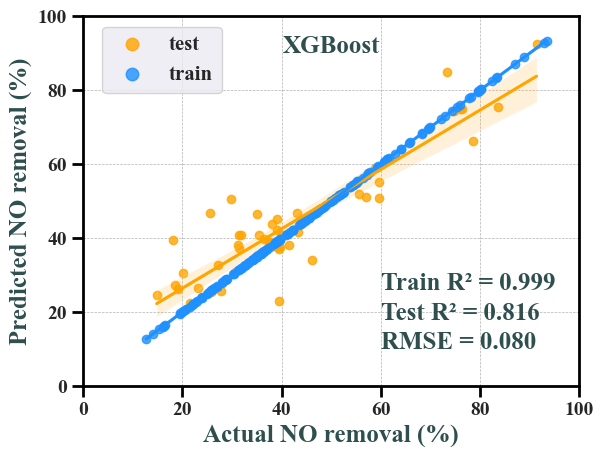

----------------------------------------------------------------------------
cv train R2: 0.559 (+/- 0.069) 

XGB Train mse: 0.00056 | rmse: 0.02366 | mae: 0.01848 | mape: 4.72320 | smape: 4.62796 | r2: 0.98172

XGB Test mse: 0.00400 | rmse: 0.06324 | mae: 0.04884 | mape: 15.23135 | smape: 13.32350 | r2: 0.88614

测试图已保存：scatter_images\XGBoost GS.jpg


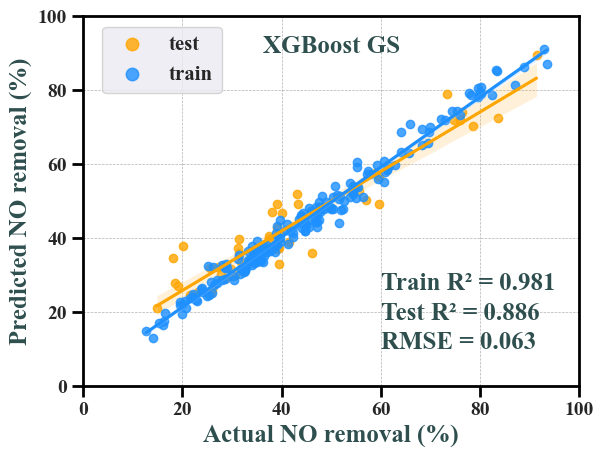

----------------------------------------------------------------------------
cv train R2: 0.490 (+/- 0.155) 

GradientBoost Train mse: 0.00142 | rmse: 0.03765 | mae: 0.02903 | mape: 7.79805 | smape: 7.46342 | r2: 0.95371

GradientBoost Test mse: 0.00598 | rmse: 0.07731 | mae: 0.06145 | mape: 19.97350 | smape: 16.83024 | r2: 0.82984

测试图已保存：scatter_images\GradientBoost.jpg


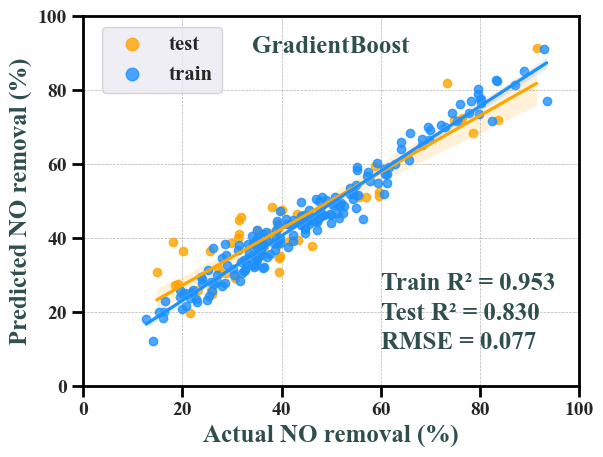

----------------------------------------------------------------------------
cv train R2: 0.526 (+/- 0.109) 

GradientBoost Train mse: 0.00001 | rmse: 0.00311 | mae: 0.00254 | mape: 0.64600 | smape: 0.64446 | r2: 0.99968

GradientBoost Test mse: 0.00368 | rmse: 0.06066 | mae: 0.04770 | mape: 14.16267 | smape: 12.85779 | r2: 0.89525

测试图已保存：scatter_images\GradientBoost GS.jpg


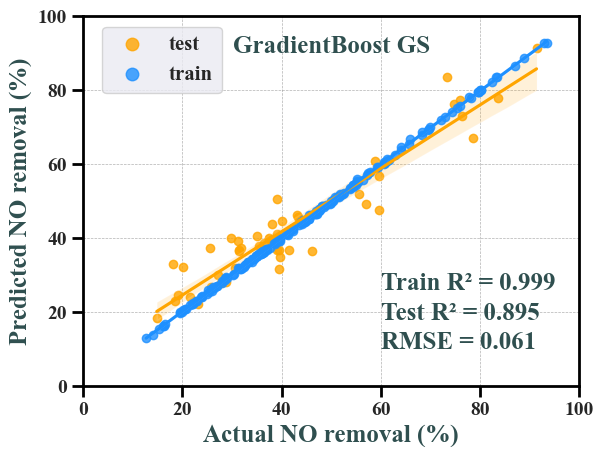

----------------------------------------------------------------------------
cv train R2: 0.553 (+/- 0.082) 

RF Train mse: 0.00164 | rmse: 0.04054 | mae: 0.03041 | mape: 8.58530 | smape: 7.92063 | r2: 0.94635

RF Test mse: 0.00584 | rmse: 0.07643 | mae: 0.06509 | mape: 20.66940 | smape: 17.83806 | r2: 0.83369

测试图已保存：scatter_images\RF Regressor.jpg


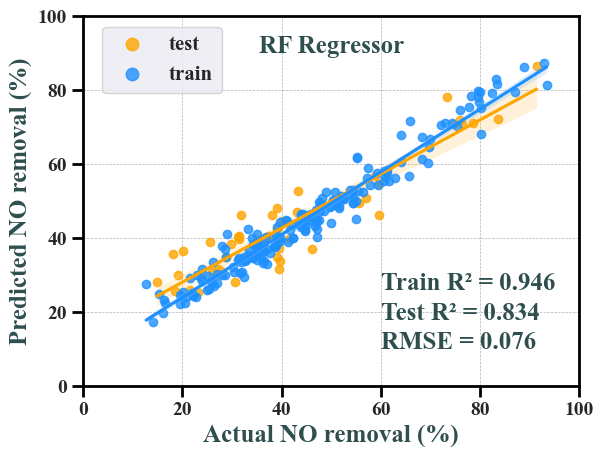

----------------------------------------------------------------------------
cv train R2: 0.573 (+/- 0.048) 

Catboost Train mse: 0.00018 | rmse: 0.01337 | mae: 0.01049 | mape: 2.61889 | smape: 2.59154 | r2: 0.99416

Catboost Test mse: 0.00414 | rmse: 0.06437 | mae: 0.05232 | mape: 16.25182 | smape: 14.46584 | r2: 0.88204

测试图已保存：scatter_images\CatBoost.jpg


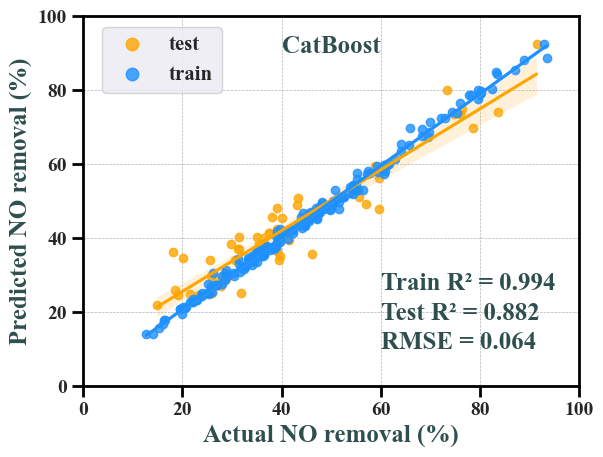

----------------------------------------------------------------------------
cv train R2: 0.560 (+/- 0.051) 

Catboost Train mse: 0.00015 | rmse: 0.01205 | mae: 0.00944 | mape: 2.35559 | smape: 2.33531 | r2: 0.99526

Catboost Test mse: 0.00348 | rmse: 0.05896 | mae: 0.04727 | mape: 14.28829 | smape: 12.89395 | r2: 0.90103

测试图已保存：scatter_images\CatBoost GS.jpg


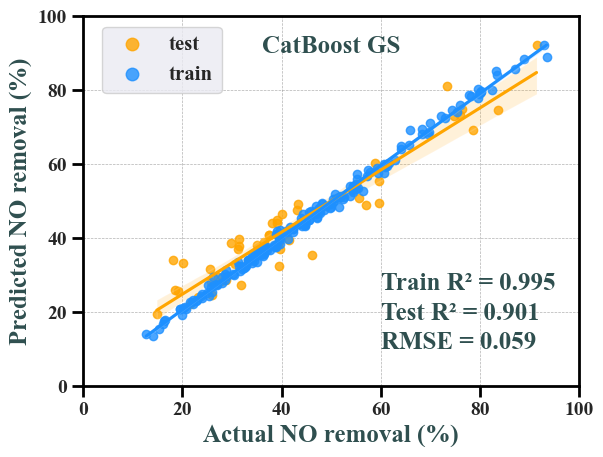

In [42]:


print("----------------------------------------------------------------------------")
xg = XGBRegressor(random_state=0)
train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
xg = XGBRegressor(colsample_bytree=1, eta=0.05, eval_metric='rmse',
                  max_depth=3, n_estimators=400, seed=2, subsample=0.5)

train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)


print("----------------------------------------------------------------------------")
gb = GradientBoostingRegressor(random_state=0)
train_pred, test_pred = process_regressor(gb, x_train, x_test, y_train, y_test)
model_performance_metrics('GradientBoost Train', y_train, train_pred)
model_performance_metrics('GradientBoost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "GradientBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
gb = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_leaf=1, min_samples_split=3,n_estimators=175, subsample=0.7, random_state=14)
train_pred, test_pred = process_regressor(gb, x_train, x_test, y_train, y_test)
model_performance_metrics('GradientBoost Train', y_train, train_pred)
model_performance_metrics('GradientBoost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "GradientBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
rf = RandomForestRegressor(random_state=0)
train_pred, test_pred = process_regressor(rf, x_train, x_test, y_train, y_test)
model_performance_metrics('RF Train', y_train, train_pred)
model_performance_metrics('RF Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "RF Regressor", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=0,verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)


In [ ]:
xg = XGBRegressor(random_state=1)
train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [ ]:
xg = XGBRegressor(colsample_bytree=1, eta=0.05, eval_metric='rmse',
                  max_depth=3, n_estimators=400, seed=2, subsample=0.5)

train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)


In [12]:
a = xg.fit(x_train, y_train)
from prepare import calculate_mre
mre_a,mre_b = calculate_mre(a, x_train, x_test,y_train, y_test)
print(mre_a,mre_b)


0.001957135180724684 0.009007049752297932


In [13]:
df_1 = pd.read_csv('prune_train.csv')
df_2 = pd.read_csv('prune_test.csv')
x_train = df_1.drop(['NO(%)'],axis=1)
x_test = df_2.drop(['NO(%)'],axis=1)
y_train = df_1['NO(%)']
y_test = df_2['NO(%)']



0.017383021285862683 0.07970639953692336
cv train R2: 0.021 (+/- 0.107) 

Catboost Train mse: 0.00008 | rmse: 0.00891 | mae: 0.00707 | mape: 1.73830 | smape: 1.72872 | r2: 0.99772

Catboost Test mse: 0.00160 | rmse: 0.03998 | mae: 0.02833 | mape: 7.97064 | smape: 7.53744 | r2: 0.94048

测试图已保存：scatter_images\prune CatBoost.jpg


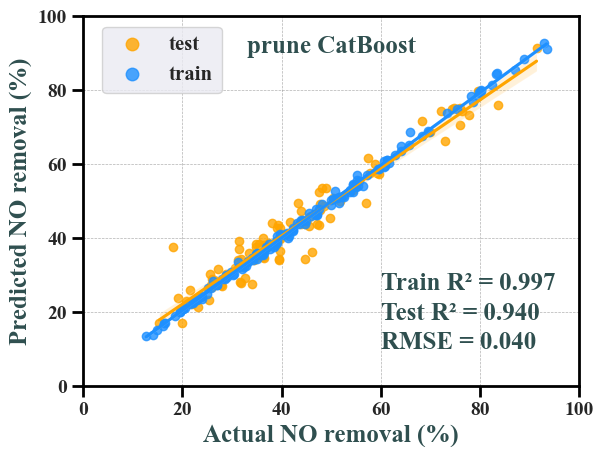

In [14]:
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)
from prepare import calculate_mre
mre_a,mre_b = calculate_mre(model, x_train, x_test,y_train, y_test)
print(mre_a,mre_b)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "prune CatBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [15]:
b = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_leaf=1, min_samples_split=3,n_estimators=175, subsample=0.7, random_state=14)
model = b.fit(x_train, y_train)
from prepare import calculate_mre
mre_a,mre_b = calculate_mre(model, x_train, x_test,y_train, y_test)
print(mre_a,mre_b)

0.007034771398183292 0.1159590285544645


In [16]:
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)
from prepare import calculate_mre
mre_a,mre_b = calculate_mre(model, x_train, x_test,y_train, y_test)
print(mre_a,mre_b)

0.017383021285862683 0.07970639953692336


In [24]:
dataset_path = 'data_filled_400.csv'
datas = pd.read_csv(dataset_path)
data = datas.drop(['element1','element2'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=0)
x_test

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
110,1,0,0,30.000000,4.000000,550,15.000000,1,0,0,25.000,0.050000,28.270000,0.600000,1129.581050,1,0,0,300,82.477260,2.716552,54.664202,74.26
149,0,0,1,10.000000,2.000000,550,10.000000,0,0,0,0.000,0.020000,95.030000,0.550000,2402.229661,0,0,1,15,7.000000,2.681378,55.800000,26.94
37,0,1,0,4.000000,4.000000,550,20.000000,1,0,0,66.670,0.200000,113.100000,0.800000,2000.000000,1,0,0,300,54.908574,2.644467,20.654782,44.81
75,1,0,0,10.000000,2.000000,550,15.000000,0,0,1,6.000,0.200000,113.100000,0.600000,2400.000000,0,0,1,30,36.141828,2.601773,39.936521,35.82
109,0,1,0,4.000000,4.000000,520,6.285765,0,0,1,4.930,0.050000,28.270000,0.600000,522.985736,1,0,0,300,8.939810,2.772400,20.961213,28.00
71,0,0,1,25.754512,4.000000,550,5.000000,1,0,0,66.670,0.050000,16.000000,0.600000,1200.000000,1,0,0,300,78.504656,2.652162,28.369911,57.52
122,0,1,0,4.000000,2.000000,600,8.769440,0,0,1,5.820,0.100000,99.110031,0.600000,2209.859205,1,0,0,500,52.123359,2.510000,32.408772,59.52
73,1,0,0,10.000000,2.000000,550,15.000000,0,0,0,0.000,0.200000,113.100000,0.600000,2400.000000,0,0,1,30,28.461133,2.700000,43.687075,31.59
153,0,0,1,10.000000,2.000000,550,10.000000,0,1,0,16.670,0.020000,95.030000,0.550000,2252.280490,0,0,1,15,11.000000,2.649974,13.480000,46.62
196,1,0,0,10.000000,2.000000,525,15.000000,1,0,0,13.380,0.227334,113.100000,0.500000,2400.000000,0,1,0,150,84.441338,2.820000,16.514113,46.70


----------------------------------------------------------------------------
cv train R2: 0.997 (+/- 0.000) 

XGB Train mse: 0.00000 | rmse: 0.00001 | mae: 0.00001 | mape: 0.00198 | smape: 0.00198 | r2: 1.00000

XGB Test mse: 0.00003 | rmse: 0.00545 | mae: 0.00365 | mape: 0.87139 | smape: 0.87649 | r2: 0.99805

测试图已保存：scatter_images\XGBoost.jpg


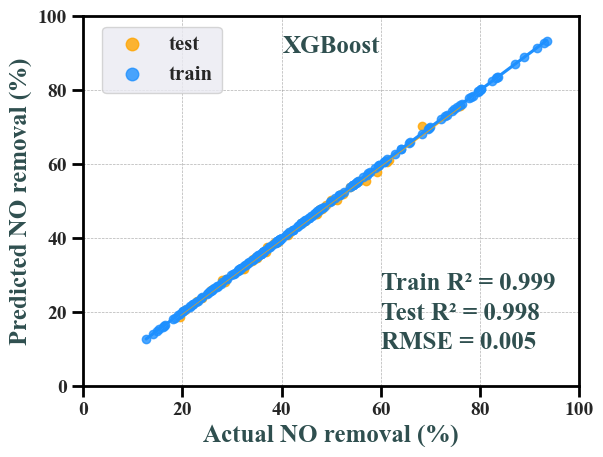

----------------------------------------------------------------------------
cv train R2: 0.998 (+/- 0.001) 

XGB Train mse: 0.00000 | rmse: 0.00109 | mae: 0.00084 | mape: 0.21705 | smape: 0.21701 | r2: 0.99997

XGB Test mse: 0.00001 | rmse: 0.00332 | mae: 0.00255 | mape: 0.61340 | smape: 0.61620 | r2: 0.99928

测试图已保存：scatter_images\XGBoost GS.jpg


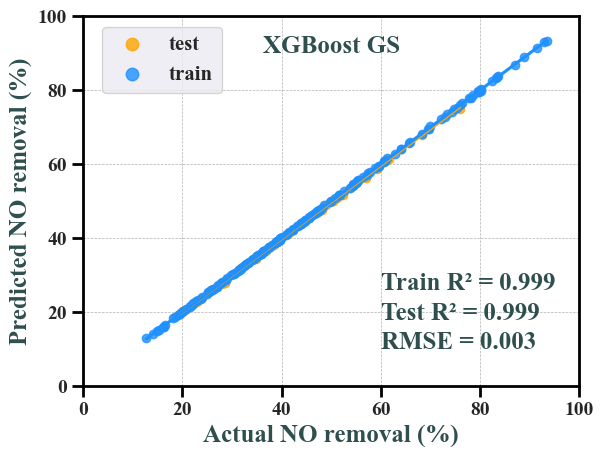

----------------------------------------------------------------------------
cv train R2: 0.999 (+/- 0.000) 

GradientBoost Train mse: 0.00000 | rmse: 0.00045 | mae: 0.00031 | mape: 0.08461 | smape: 0.08461 | r2: 0.99999

GradientBoost Test mse: 0.00000 | rmse: 0.00183 | mae: 0.00142 | mape: 0.35513 | smape: 0.35516 | r2: 0.99978

测试图已保存：scatter_images\GradientBoost.jpg


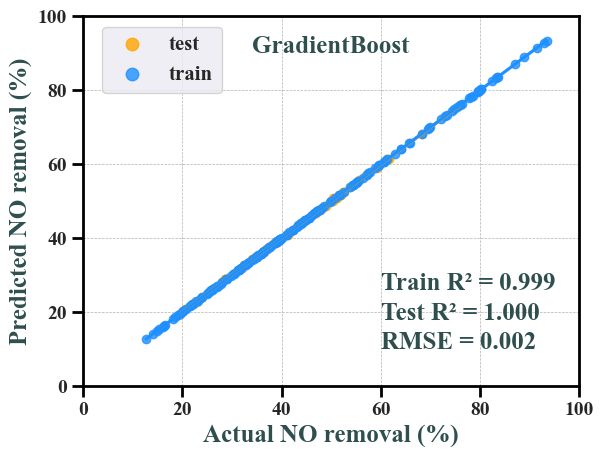

----------------------------------------------------------------------------
cv train R2: 0.999 (+/- 0.001) 

GradientBoost Train mse: 0.00000 | rmse: 0.00005 | mae: 0.00003 | mape: 0.00742 | smape: 0.00742 | r2: 1.00000

GradientBoost Test mse: 0.00000 | rmse: 0.00182 | mae: 0.00129 | mape: 0.30349 | smape: 0.30372 | r2: 0.99978

测试图已保存：scatter_images\GradientBoost GS.jpg


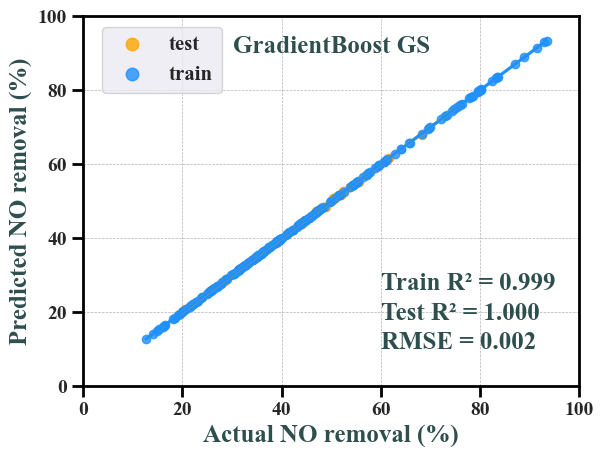

----------------------------------------------------------------------------
cv train R2: 0.998 (+/- 0.001) 

RF Train mse: 0.00001 | rmse: 0.00235 | mae: 0.00135 | mape: 0.34576 | smape: 0.34358 | r2: 0.99985

RF Test mse: 0.00001 | rmse: 0.00237 | mae: 0.00162 | mape: 0.41577 | smape: 0.41751 | r2: 0.99963

测试图已保存：scatter_images\RF Regressor.jpg


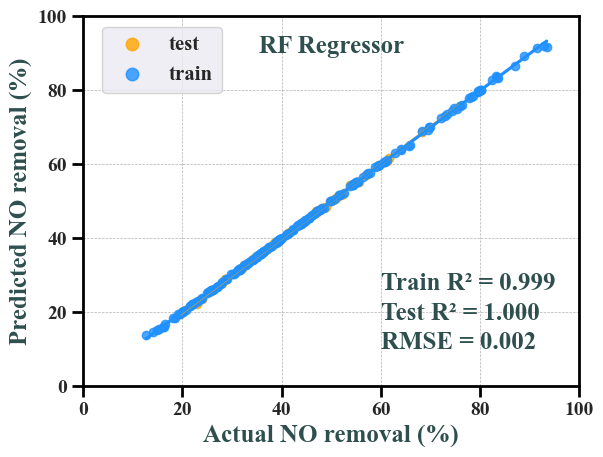

----------------------------------------------------------------------------
cv train R2: 0.980 (+/- 0.012) 

Catboost Train mse: 0.00000 | rmse: 0.00140 | mae: 0.00112 | mape: 0.28647 | smape: 0.28641 | r2: 0.99994

Catboost Test mse: 0.00012 | rmse: 0.01116 | mae: 0.00844 | mape: 2.14791 | smape: 2.13368 | r2: 0.99181

测试图已保存：scatter_images\CatBoost.jpg


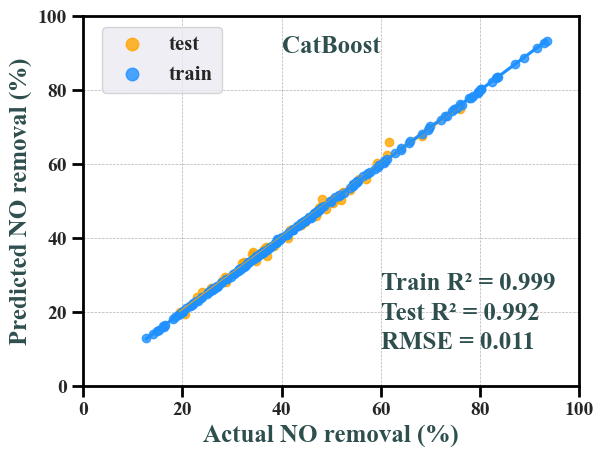

----------------------------------------------------------------------------
cv train R2: 0.988 (+/- 0.008) 

Catboost Train mse: 0.00000 | rmse: 0.00101 | mae: 0.00081 | mape: 0.20916 | smape: 0.20914 | r2: 0.99997

Catboost Test mse: 0.00010 | rmse: 0.00994 | mae: 0.00730 | mape: 1.74095 | smape: 1.73292 | r2: 0.99349

测试图已保存：scatter_images\CatBoost GS.jpg


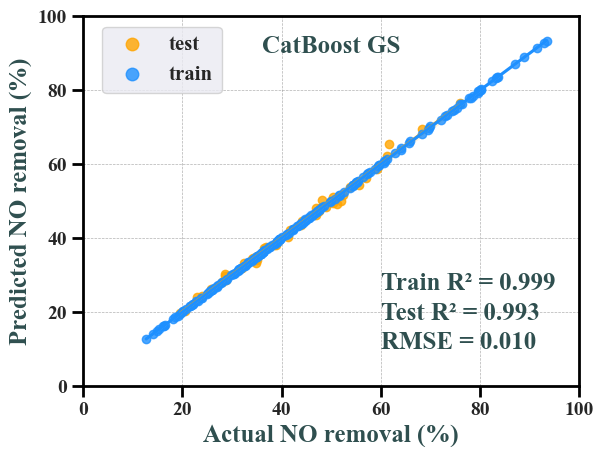

In [25]:
dataset_path = 'data_filled_400.csv'
datas = pd.read_csv(dataset_path)
data = datas.drop(['element1','element2'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=10)

print("----------------------------------------------------------------------------")
xg = XGBRegressor(random_state=0)
train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
xg = XGBRegressor(colsample_bytree=1, eta=0.05, eval_metric='rmse',
                  max_depth=3, n_estimators=400, seed=2, subsample=0.5)

train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "XGBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)


print("----------------------------------------------------------------------------")
gb = GradientBoostingRegressor(random_state=0)
train_pred, test_pred = process_regressor(gb, x_train, x_test, y_train, y_test)
model_performance_metrics('GradientBoost Train', y_train, train_pred)
model_performance_metrics('GradientBoost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "GradientBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
gb = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_leaf=1, min_samples_split=3,n_estimators=175, subsample=0.7, random_state=14)
train_pred, test_pred = process_regressor(gb, x_train, x_test, y_train, y_test)
model_performance_metrics('GradientBoost Train', y_train, train_pred)
model_performance_metrics('GradientBoost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "GradientBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
rf = RandomForestRegressor(random_state=0)
train_pred, test_pred = process_regressor(rf, x_train, x_test, y_train, y_test)
model_performance_metrics('RF Train', y_train, train_pred)
model_performance_metrics('RF Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "RF Regressor", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

print("----------------------------------------------------------------------------")
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=0,verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost GS", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [17]:
for i in range(100):
    catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=i,verbose=False)
    train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
    model_performance_metrics('Catboost Test', y_test, test_pred)


cv train R2: 0.560 (+/- 0.051) 

Catboost Test mse: 0.00348 | rmse: 0.05896 | mae: 0.04727 | mape: 14.28829 | smape: 12.89395 | r2: 0.90103

cv train R2: 0.563 (+/- 0.041) 

Catboost Test mse: 0.00394 | rmse: 0.06279 | mae: 0.05119 | mape: 15.45813 | smape: 14.01857 | r2: 0.88775

cv train R2: 0.546 (+/- 0.067) 

Catboost Test mse: 0.00386 | rmse: 0.06209 | mae: 0.05102 | mape: 15.60148 | smape: 14.08789 | r2: 0.89025

cv train R2: 0.561 (+/- 0.049) 

Catboost Test mse: 0.00387 | rmse: 0.06221 | mae: 0.04990 | mape: 15.22432 | smape: 13.82792 | r2: 0.88983

cv train R2: 0.564 (+/- 0.046) 

Catboost Test mse: 0.00411 | rmse: 0.06413 | mae: 0.05365 | mape: 16.32677 | smape: 14.67424 | r2: 0.88290

cv train R2: 0.563 (+/- 0.038) 

Catboost Test mse: 0.00387 | rmse: 0.06219 | mae: 0.05015 | mape: 15.60376 | smape: 13.95679 | r2: 0.88988

cv train R2: 0.568 (+/- 0.040) 

Catboost Test mse: 0.00386 | rmse: 0.06211 | mae: 0.05182 | mape: 15.51999 | smape: 14.03434 | r2: 0.89017

cv train R2: 